In [8]:
import sys
import os
import math
import glob
import time
import torch
from torchsummary import summary
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
sys.path.append('..')

# Project modules
from src.utility.config import (
    DEVICE, 
    CSV_DIR,
    BASELINE_MODEL_PATH, 
    QUANTIZED_MODELS, 
)
from src.utility.quantizer import Quantization
from src.utility.utils import get_data_loaders
from src.model import CNN
from src.layers import QuantizedLayerMixin
from src.utility.utils import apply_fx_quantization

CONFIG = {
    "baseline_path": BASELINE_MODEL_PATH,
    "quant_model_name": "Aff_INT8", # Nur hier ändern!
    "batch_size": 32,
    "vis_samples": 50
}

sns.set_theme(style="whitegrid")

In [9]:
def check_fx_quantization_type(model):
    """
    Spezielle Prüf-Funktion für FX Graph Mode Modelle.
    Sucht nach 'PackedParams', entpackt sie und prüft das Quantisierungs-Schema.
    """
    print("--- FX Quantisierungs-Check ---")
    found = False
    
    # Wir iterieren durch alle Attribute des Modells
    # FX speichert Gewichte oft als Attribute wie 'conv1_packed_weight_0'
    for name in dir(model):
        attr = getattr(model, name)
        
        # Prüfung: Ist es ein gepacktes Gewichtspaket?
        # Diese Objekte haben meist eine .unpack() Methode
        if hasattr(attr, 'unpack') and "packed_weight" in name:
            print(f"Untersuche Parameter-Paket: '{name}'")
            
            # Entpacken (gibt meist Weight, Bias zurück)
            try:
                weight, bias = attr.unpack()
                
                # Jetzt haben wir den echten quantisierten Tensor
                scheme = weight.qscheme()
                print(f"  QScheme: {scheme}")
                
                # Check auf Zero Point (der mathematische Beweis)
                if scheme in [torch.per_channel_symmetric, torch.per_tensor_symmetric]:
                    # Bei Symmetric muss ZP überall 0 sein
                    zps = weight.q_zero_point()
                    # Wenn zps ein Tensor ist, prüfen wir alle Werte
                    if torch.all(zps == 0):
                        print("  -> BESTÄTIGT: Symmetrisch (Alle Zero-Points sind 0).")
                    else:
                        print("  -> WARNUNG: Schema ist symmetrisch, aber Zero-Points sind ungleich 0!")
                        
                elif scheme in [torch.per_channel_affine, torch.per_tensor_affine]:
                    print("  -> BESTÄTIGT: Affine (Asymmetrisch).")
                
                found = True
                break # Ein Treffer reicht uns
            except Exception as e:
                print(f"  Konnte Paket nicht entpacken: {e}")

    if not found:
        print("Keine gepackten Gewichte gefunden. (Vielleicht ist das Modell noch Float?)")

In [ ]:
def _fix_quantization_dtypes(module, method='symmetric', bits=8):
    """
    Interne Hilfsfunktion: Setzt Flags und repariert Float->Int Casts für einen Layer.
    """
    module.quant_method = method
    module.num_bits = bits
    module.quant_mode = True
    
    if hasattr(module, 'act_scale') and module.act_scale.item() != 1.0:
        module.activation_calibrated = True
        
    if method == 'affine':
        target_dtype = torch.uint8
    else: # symmetric / power2
        target_dtype = torch.int8
        
    if hasattr(module, 'weight') and module.weight.dtype == torch.float32:
        module.weight = nn.Parameter(module.weight.data.to(target_dtype), requires_grad=False)

def load_model(model_class, num_classes, model_path, quant_config=None):
    """
    Universal-Loader für Baseline UND Quantisierte Modelle.
    """
    model = model_class(num_classes=num_classes).to(DEVICE)
    
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Modell nicht gefunden: {model_path}")
        
    state_dict = torch.load(model_path, map_location=DEVICE)
    model.load_state_dict(state_dict)
    
    if quant_config:
        print(f"Repariere Quantisierung ({quant_config})...")
        method = quant_config.get('method', 'affine')
        bits = quant_config.get('bits', 8)

        for name, module in model.named_modules():
            # Wir prüfen duck-typing oder Klasse
            if hasattr(module, "quant_mode") or isinstance(module, QuantizedLayerMixin):
             _fix_quantization_dtypes(module, method, bits)
    else:
        print(" Baseline Modus (Float32).")
        if hasattr(model, 'convert_to_baseline'):
            model.convert_to_baseline()
            
    model.eval()
    return model

In [11]:
def get_all_predictions(model, data_loader, device):
    """
    Führt Inferenz auf dem gesamten Loader durch und gibt rohe Listen/Arrays zurück.
    Kein Plotting hier! Nur Datenverarbeitung.
    """
    model.eval()
    model.to(device)
    all_preds = []
    all_targets = []

    sample_images = []
    
    with torch.no_grad():
        for i, (data, target) in enumerate(data_loader):
            data = data.to(device)

            output = model(data)
            pred = output.argmax(dim=1).cpu().numpy()

            all_preds.extend(pred)
            all_targets.extend(target.numpy())

            if i == 0:
                sample_images = data.cpu()
            
    return {
        "preds": np.array(all_preds),
        "targets": np.array(all_targets),
        "sample_images": sample_images
    }

def print_metrics(results_dict, model_name="Model"):
    # TODO: Berechne Accuracy, Precision, Recall basierend auf results_dict['preds'] und ['targets']
    # Nutze sklearn classification_report
    acc = accuracy_score(results_dict['targets'], results_dict['preds'])
    error_rate = 1.0 - acc

    print(f"\n--- Performance: {model_name} ---")
    print(f"Accuracy:   {acc:.4f} ({acc*100:.2f}%)")
    print(f"Error Rate: {error_rate:.4f} ({error_rate*100:.2f}%)")
    print("-" * 40)

    print(classification_report(results_dict['targets'], results_dict['preds'], digits=4))

In [12]:
def measure_inference_time(model, data_loader, device='cpu', num_batches=100):
    model.to(device)
    model.eval()
    
    # 1. Warm-up (Wichtig für stabile Werte)
    # Wir schicken 5 Batches durch, zählen die Zeit aber nicht
    print(f"Warm-up auf {device}...")
    with torch.no_grad():
        for i, (data, _) in enumerate(data_loader):
            if i >= 5: break
            data = data.to(device)
            model(data)
            
    # 2. Echte Messung
    print(f"Starte Messung ({num_batches} Batches)...")
    start_time = time.time()
    count = 0
    
    with torch.no_grad():
        for i, (data, _) in enumerate(data_loader):
            if i >= num_batches: break
            data = data.to(device)
            model(data)
            count += data.size(0) # Anzahl der Bilder im Batch addieren
            
    end_time = time.time()
    
    # Metriken berechnen
    total_time = end_time - start_time
    fps = count / total_time
    latency_ms = (total_time / count) * 1000
    
    return fps, latency_ms

In [13]:
def plot_confusion_matrix(targets, preds, class_names, title="Confusion Matrix"):
    """Plottet eine saubere Confusion Matrix der Top-Klassen"""
    # Wir nehmen nur die häufigsten Klassen, damit der Plot lesbar bleibt
    from collections import Counter
    TOP_N = 15
    
    counts = Counter(targets)
    top_classes_idx = [c for c, _ in counts.most_common(TOP_N)]
    
    # Filtern
    mask = np.isin(targets, top_classes_idx) & np.isin(preds, top_classes_idx)
    filt_targets = targets[mask]
    filt_preds = preds[mask]
    
    cm = confusion_matrix(filt_targets, filt_preds, labels=top_classes_idx)
    
    # Namen mappen
    if class_names:
        labels = [class_names[i] for i in top_classes_idx]
    else:
        labels = top_classes_idx

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.title(f"{title} (Top {TOP_N} Classes)")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

def plot_visual_comparison(images, preds_base, preds_quant, targets, class_names, num_samples=32):
    """
    Zeigt Bilder im Raster an.
    Farben: Grün (beide korrekt), Rot (beide falsch), Orange (Quantisierung weicht ab).
    """
    # Wir nutzen nur so viele Bilder, wie wir haben
    n = min(len(images), num_samples, len(preds_base))
    
    cols = 8
    rows = math.ceil(n / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 3.0 * rows))
    axes = axes.flatten()
    
    print(f"Visualisiere {n} Beispiele...")
    
    for i in range(n):
        ax = axes[i]
        
        # Bild normalisieren für Anzeige (angenommen -1..1 Range)
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * 0.5) + 0.5 
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        
        p_base = preds_base[i]
        p_quant = preds_quant[i]
        true_lbl = targets[i]
        
        # Logik für Titel-Farbe
        is_diff = (p_base != p_quant)
        is_correct = (p_quant == true_lbl)
        
        if is_diff:
            color = 'orange'
            box_text = "DIFF"
        elif is_correct:
            color = 'green'
            box_text = "OK"
        else:
            color = 'red'
            box_text = "ERR"
            
        # Klassen-Namen holen
        name_q = class_names[p_quant] if class_names else str(p_quant)
        # name_t = class_names[true_lbl] if class_names else str(true_lbl)
        
        title = f"Q: {name_q}\n[{box_text}]"
        ax.set_title(title, color=color, fontweight='bold', fontsize=9)
        ax.axis('off')
        
    # Restliche Achsen ausschalten
    for j in range(n, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

def plot_weight_distribution(model, layer_type=nn.Conv2d):
    """Zeigt die Gewichtsverteilung als Boxplot"""
    data = []
    labels = []
    
    for name, module in model.named_modules():
        if isinstance(module, layer_type):
            w = module.weight.detach().cpu().numpy().flatten()
            data.append(w)
            labels.append(name)
            
    if not data:
        print("Keine Layer für Weight-Plot gefunden.")
        return

    plt.figure(figsize=(12, 6))
    plt.boxplot(data, tick_labels=labels, showfliers=False)
    plt.xticks(rotation=90)
    plt.title(f"Gewichtsverteilung ({layer_type.__name__})")
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

 Baseline Modus (Float32).
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   QuantizedConv2d-1           [-1, 32, 64, 64]             896
   QuantizedConv2d-2           [-1, 64, 64, 64]          18,496
   QuantizedConv2d-3          [-1, 128, 64, 64]          73,856
   QuantizedConv2d-4          [-1, 256, 64, 64]         295,168
 AdaptiveAvgPool2d-5            [-1, 256, 2, 2]               0
           Dropout-6                 [-1, 1024]               0
   QuantizedLinear-7                 [-1, 1024]       1,049,600
   QuantizedLinear-8                  [-1, 150]         153,750
Total params: 1,591,766
Trainable params: 1,591,766
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.05
Forward/backward pass size (MB): 15.02
Params size (MB): 6.07
Estimated Total Size (MB): 21.14
----------------------------------------------------------------
Repariere

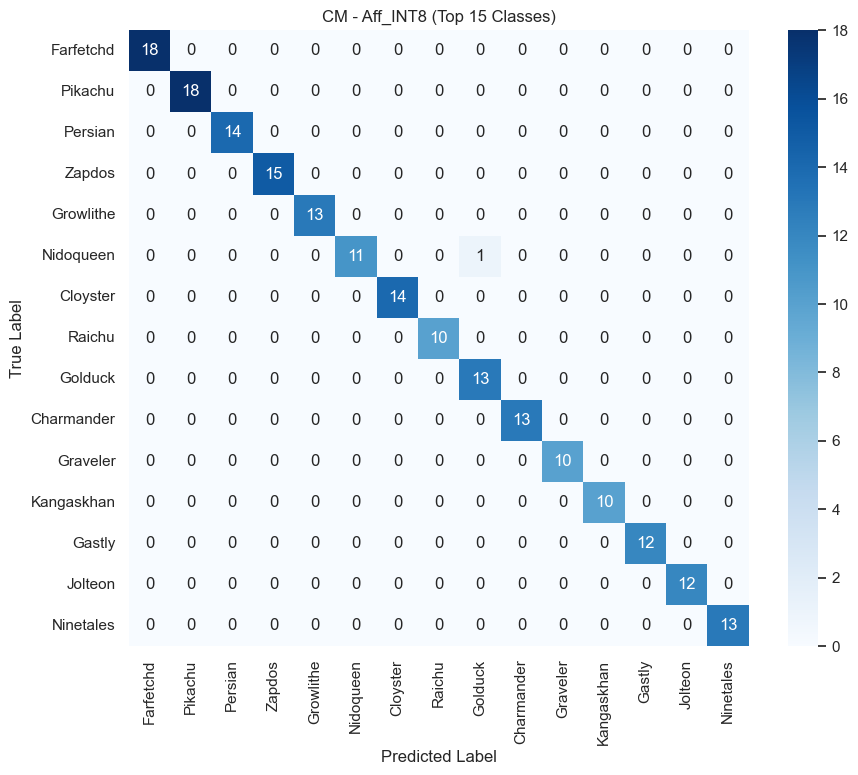

In [14]:
train_loader, test_loader, num_classes = get_data_loaders()

# Versuche Klassennamen zu finden

class_names = getattr(test_loader.dataset, 'classes', None)
if not class_names and hasattr(test_loader.dataset, 'dataset'):
    class_names = getattr(test_loader.dataset.dataset, 'classes', None)


# 2. Config ableiten (Automatisch aus dem Namen)

q_name = CONFIG['quant_model_name']
q_method = 'affine' if 'Affine' in q_name else 'symmetric'
if 'Po2' in q_name: q_method = 'power2'
q_bits = 4 if 'INT4' in q_name else 8


# 3. Modelle laden

# A) Baseline

baseline_model = load_model(CNN, num_classes, CONFIG['baseline_path'])
summary(baseline_model, input_size=(3,64,64))


# B) Quantized
q_path = os.path.join(QUANTIZED_MODELS, f"model_{q_name}.pt")
quantized_model = load_model(
    CNN,
    num_classes,
    q_path,
    quant_config={'method': q_method, 'bits': q_bits}
)


quantized_model = apply_fx_quantization(baseline_model, train_loader,method="affine", num_batches=30)
print(quantized_model.print_readable())


print("Evaluiere Accuracy...")

# Baseline (kannst du auch auf GPU laufen lassen, wenn du willst, aber für Vergleich ist CPU sauberer)
res_base = get_all_predictions(baseline_model, test_loader, device='cpu')
print_metrics(res_base, "Baseline Float32")

# Quantized (MUSS auf CPU sein)
res_quant = get_all_predictions(quantized_model, test_loader, device='cpu')
print_metrics(res_quant, "Quantized FX Int8")


# --- B. Speed Check (Geschwindigkeit) ---
print("\nEvaluiere Geschwindigkeit (auf CPU)...")

# Messung Baseline
fps_base, lat_base = measure_inference_time(baseline_model, test_loader, device='cpu')
print(f"Baseline:  {fps_base:.2f} Bilder/sek | Latenz: {lat_base:.2f} ms")

# Messung Quantized
fps_quant, lat_quant = measure_inference_time(quantized_model, test_loader, device='cpu')
print(f"Quantized: {fps_quant:.2f} Bilder/sek | Latenz: {lat_quant:.2f} ms")

# Speedup berechnen
speedup = fps_quant / fps_base
print(f"\n-> Beschleunigung: {speedup:.2f}x schneller")


# print_metrics(res_base, "Baseline Float32")
# print_metrics(res_quant, f"Quantized {q_name}")


# 5. Visualisierung
# A) Verwirrungsmatrix (Vergleich)
plot_confusion_matrix(res_quant['targets'], res_quant['preds'], class_names, title=f"CM - {q_name}") 